# Notebook 2 — Model A: Baseline U-Net (EfficientNet-B4 Encoder)

**Architecture:** Standard U-Net, EfficientNet-B4 encoder (ImageNet-pretrained), implemented
using **Segmentation Models PyTorch (SMP)** — per the spec, SMP is used **only** for Model A.
Models B and C (Notebooks 3 and 4) implement the Attention U-Net manually, without any
Attention U-Net library.

**Loss:** Dice Loss + Binary Cross-Entropy Loss
**Optimizer:** AdamW (lr=1e-4, weight_decay=1e-4)
**Scheduler:** Cosine Annealing (min lr=1e-6)
**Epochs:** 80, with early stopping (patience=15, monitored on validation IoU)
**Mixed precision:** Enabled

This notebook re-establishes the data pipeline from Notebook 1 (so it is independently
executable), then defines, trains, and evaluates Model A.


## 1. Setup, Drive Mount, and Re-establishing the Data Pipeline

In [ ]:
!pip install -q segmentation-models-pytorch==0.3.4
!pip install -q albumentations==1.4.15
!pip install -q opencv-python-headless
print("Package installation complete.")


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 kB 8.7 MB/s eta 0:00:00
Package installation complete.


In [ ]:
# ==========================================================
# Install compatible versions
# ==========================================================

!pip install -q --upgrade pip
!pip uninstall -y albumentations albucore opencv-python-headless

!pip install -q \
albumentations==1.4.18 \
albucore==0.0.17 \
opencv-python-headless==4.10.0.84 \
segmentation-models-pytorch \
timm

print("Installation Complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 28.1 MB/s eta 0:00:00
Found existing installation: albumentations 1.4.15
Uninstalling albumentations-1.4.15:
  Successfully uninstalled albumentations-1.4.15
Found existing installation: albucore 0.0.24
Uninstalling albucore-0.0.24:
  Successfully uninstalled albucore-0.0.24
Found existing installation: opencv-python-headless 4.13.0.92
Uninstalling opencv-python-headless-4.13.0.92:
  Successfully uninstalled opencv-python-headless-4.13.0.92
Installation Complete.


In [ ]:
import os
import glob
import random
import time
import json
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Mixed Precision
try:
    from torch.amp import autocast, GradScaler
except ImportError:
    from torch.cuda.amp import autocast, GradScaler

# Albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Segmentation Models
import segmentation_models_pytorch as smp

# Metrics
from sklearn.metrics import precision_score, recall_score, f1_score

print("=" * 60)
print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device          :", DEVICE)

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))

# ----------------------------------------------------
# Reproducibility
# ----------------------------------------------------
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

PyTorch Version : 2.11.0+cu128
CUDA Available  : True
Device          : cuda
GPU             : Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# ----------------------------------------------------------------------------
# CONFIGURABLE PATHS (identical convention to Notebook 1)
# ----------------------------------------------------------------------------
DRIVE_ROOT = "/content/drive/MyDrive"
DATASET_DIR_NAME = "oil spills"
DATASET_ROOT = os.path.join(DRIVE_ROOT, DATASET_DIR_NAME)

SPLIT_DIRS = {
    "train": os.path.join(DATASET_ROOT, "train"),
    "val":   os.path.join(DATASET_ROOT, "val"),
    "test":  os.path.join(DATASET_ROOT, "test"),
}
LABEL_COLORS_PATH = os.path.join(DATASET_ROOT, "label_colors.txt")

PROJECT_OUTPUT_DIR = os.path.join(DRIVE_ROOT, "oil_spill_project_outputs")
CHECKPOINT_DIR = os.path.join(PROJECT_OUTPUT_DIR, "checkpoints")
METRICS_DIR = os.path.join(PROJECT_OUTPUT_DIR, "metrics")
PRED_DIR = os.path.join(PROJECT_OUTPUT_DIR, "predictions")
PLOTS_DIR = os.path.join(PROJECT_OUTPUT_DIR, "plots")

for d in [PROJECT_OUTPUT_DIR, CHECKPOINT_DIR, METRICS_DIR, PRED_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

IMG_SIZE = 512
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
BATCH_SIZE = 8
NUM_WORKERS = min(os.cpu_count() or 2, 4)

print("Dataset root:", DATASET_ROOT)


Dataset root: /content/drive/MyDrive/oil spills


### 1.1 Data Pipeline (condensed from Notebook 1)

The full exploratory analysis lives in Notebook 1. Here we re-define only what training
needs: label color parsing, binarization, CopyPaste, the `Dataset` class, transforms, and
loaders — kept **identical** to Notebook 1 so results are directly comparable.


In [ ]:
# ==========================================================
# Dataset Helper Functions
# ==========================================================

def load_rgb(path):
    img = cv2.imread(path)

    if img is None:
        raise FileNotFoundError(f"Could not read image: {path}")

    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def list_image_mask_pairs(split_dir):
    """
    Returns list of (image_path, mask_path)
    """

    img_dir = os.path.join(split_dir, "images")
    mask_dir = os.path.join(split_dir, "masks")

    img_paths = sorted(glob.glob(os.path.join(img_dir, "*")))

    mask_dict = {
        os.path.splitext(os.path.basename(p))[0]: p
        for p in glob.glob(os.path.join(mask_dir, "*"))
    }

    pairs = []

    for img_path in img_paths:

        stem = os.path.splitext(os.path.basename(img_path))[0]

        candidates = [
            stem,
            stem + "_L",
            stem.replace("_L", "")
        ]

        for c in candidates:
            if c in mask_dict:
                pairs.append((img_path, mask_dict[c]))
                break

    return pairs


def parse_label_colors(path):
    """
    Reads label_colors.txt

    Expected format:
    R G B LabelName
    """

    if not os.path.exists(path):
        raise FileNotFoundError(f"label_colors.txt not found:\n{path}")

    label_map = {}

    with open(path, "r") as f:

        for line in f:

            line = line.strip()

            if line == "":
                continue

            parts = line.split()

            if len(parts) < 4:
                continue

            r, g, b = map(int, parts[:3])

            label = " ".join(parts[3:])

            label_map[label] = (r, g, b)

    return label_map


def identify_oil_color(label_colors, mask_sample_paths, max_samples=20):
    """
    Find oil RGB color.
    """

    # Prefer explicit oil label
    for label, rgb in label_colors.items():

        if "oil" in label.lower():
            return rgb, label

    # Otherwise infer rarest color
    color_counts = {}

    for p in mask_sample_paths[:max_samples]:

        mask = load_rgb(p)

        colors, counts = np.unique(
            mask.reshape(-1, 3),
            axis=0,
            return_counts=True
        )

        for c, n in zip(colors, counts):

            key = tuple(c.tolist())

            color_counts[key] = color_counts.get(key, 0) + int(n)

    if len(color_counts) == 0:
        raise RuntimeError("Could not infer oil color. No mask images found.")

    rarest = min(color_counts, key=color_counts.get)

    return rarest, "oil (inferred)"


def rgb_mask_to_binary(mask_rgb, oil_color, tolerance=10):
    """
    Convert RGB mask to binary mask.
    """

    oil_color = np.array(oil_color, dtype=np.int16)

    diff = np.abs(
        mask_rgb.astype(np.int16)
        - oil_color.reshape(1, 1, 3)
    )

    binary = np.all(diff <= tolerance, axis=-1)

    return binary.astype(np.uint8)


# ==========================================================
# Build Dataset
# ==========================================================

print("Dataset Root:", DATASET_ROOT)
print("Label Colors File:", LABEL_COLORS_PATH)
print("Label Colors Exists:", os.path.exists(LABEL_COLORS_PATH))

dataset_pairs = {
    split: list_image_mask_pairs(path)
    for split, path in SPLIT_DIRS.items()
}

label_colors = parse_label_colors(LABEL_COLORS_PATH)

OIL_COLOR, OIL_NAME = identify_oil_color(
    label_colors,
    [mask_path for _, mask_path in dataset_pairs["train"][:20]]
)

print("\nDataset Summary")
print("-" * 35)

for split in dataset_pairs:
    print(f"{split:<6}: {len(dataset_pairs[split])} image-mask pairs")

print("\nOil Label :", OIL_NAME)
print("Oil Color :", OIL_COLOR)

Dataset Root: /content/drive/MyDrive/oil spills
Label Colors File: /content/drive/MyDrive/oil spills/label_colors.txt
Label Colors Exists: True

Dataset Summary
-----------------------------------
train : 811 image-mask pairs
val   : 203 image-mask pairs
test  : 254 image-mask pairs

Oil Label : oil
Oil Color : (255, 0, 124)


In [ ]:
def extract_oil_object(image, binary_mask):
    ys, xs = np.where(binary_mask > 0)
    if len(ys) == 0:
        return None, None
    y_min, y_max = ys.min(), ys.max() + 1
    x_min, x_max = xs.min(), xs.max() + 1
    return (image[y_min:y_max, x_min:x_max].copy(), binary_mask[y_min:y_max, x_min:x_max].copy()), (y_min, x_min, y_max, x_max)


def find_paste_location(target_mask, object_shape, max_attempts=10):
    H, W = target_mask.shape
    oh, ow = object_shape
    if oh >= H or ow >= W:
        return None
    best_loc, best_overlap = None, None
    for _ in range(max_attempts):
        oy, ox = random.randint(0, H - oh), random.randint(0, W - ow)
        overlap = target_mask[oy:oy + oh, ox:ox + ow].sum()
        if overlap == 0:
            return (oy, ox)
        if best_overlap is None or overlap < best_overlap:
            best_overlap, best_loc = overlap, (oy, ox)
    return best_loc


def copy_paste_augment(src_image, src_mask, dst_image, dst_mask):
    extracted, _ = extract_oil_object(src_image, src_mask)
    if extracted is None:
        return dst_image, dst_mask
    obj_image, obj_mask = extracted
    oh, ow = obj_mask.shape
    loc = find_paste_location(dst_mask, (oh, ow))
    if loc is None:
        return dst_image, dst_mask
    oy, ox = loc
    new_image, new_mask = dst_image.copy(), dst_mask.copy()
    region_bool = obj_mask.astype(bool)
    region_img = new_image[oy:oy + oh, ox:ox + ow]
    region_img[region_bool] = obj_image[region_bool]
    new_image[oy:oy + oh, ox:ox + ow] = region_img
    region_mask = new_mask[oy:oy + oh, ox:ox + ow]
    new_mask[oy:oy + oh, ox:ox + ow] = np.logical_or(region_mask.astype(bool), region_bool).astype(dst_mask.dtype)
    return new_image, new_mask


In [ ]:
class OilSpillDataset(Dataset):
    def __init__(self, pairs, oil_color, transform, use_copypaste=False, copypaste_prob=0.5):
        self.pairs = pairs
        self.oil_color = oil_color
        self.transform = transform
        self.use_copypaste = use_copypaste
        self.copypaste_prob = copypaste_prob

    def __len__(self):
        return len(self.pairs)

    def _load_binary_mask(self, mask_path):
        return rgb_mask_to_binary(load_rgb(mask_path), self.oil_color)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        image = load_rgb(img_path)
        mask = self._load_binary_mask(mask_path)

        if self.use_copypaste and random.random() < self.copypaste_prob:
            src_img_path, src_mask_path = random.choice(self.pairs)
            try:
                src_image = load_rgb(src_img_path)
                src_mask = self._load_binary_mask(src_mask_path)
                image, mask = copy_paste_augment(src_image, src_mask, image, mask)
            except Exception:
                pass

        transformed = self.transform(image=image, mask=mask)
        image_tensor = transformed["image"]
        mask_tensor = transformed["mask"].long().unsqueeze(0).float()
        return image_tensor, mask_tensor


def get_train_augmentations(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Rotate(limit=30, p=0.5, border_mode=cv2.BORDER_CONSTANT),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.CoarseDropout(num_holes_range=(4, 8), hole_height_range=(0.03, 0.08),
                         hole_width_range=(0.03, 0.08), fill=0, fill_mask=0, p=0.3),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


def get_val_test_augmentations(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


train_dataset = OilSpillDataset(dataset_pairs["train"], OIL_COLOR, get_train_augmentations(),
                                 use_copypaste=True, copypaste_prob=0.5)
val_dataset = OilSpillDataset(dataset_pairs["val"], OIL_COLOR, get_val_test_augmentations())
test_dataset = OilSpillDataset(dataset_pairs["test"], OIL_COLOR, get_val_test_augmentations())

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"train: {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"val:   {len(val_dataset)} samples, {len(val_loader)} batches")
print(f"test:  {len(test_dataset)} samples, {len(test_loader)} batches")


train: 811 samples, 101 batches
val:   203 samples, 26 batches
test:  254 samples, 32 batches


## 2. Model A — Standard U-Net with EfficientNet-B4 Encoder (SMP)

Per the spec, **SMP is used only for Model A**. This establishes whether the EfficientNet-B4
encoder alone (without attention or boundary-aware losses) is sufficient — the baseline
against which Models B and C are compared in the ablation study (Notebook 5).


In [ ]:
def build_model_a():
    """
    Model A: standard U-Net, EfficientNet-B4 encoder, ImageNet-pretrained,
    single output class (binary oil segmentation), no final activation
    (raw logits returned - sigmoid applied inside the loss / at inference time).
    """
    model = smp.Unet(
        encoder_name="timm-efficientnet-b4",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        activation=None,
    )
    return model

model_a = build_model_a().to(DEVICE)
n_params = sum(p.numel() for p in model_a.parameters())
n_trainable = sum(p.numel() for p in model_a.parameters() if p.requires_grad)
print(f"Model A parameter count: {n_params:,} total, {n_trainable:,} trainable")


Downloading: "https://github.com/huggingface/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_b4-74ee3bed.pth" to /root/.cache/torch/hub/checkpoints/tf_efficientnet_b4-74ee3bed.pth


100%|██████████| 74.4M/74.4M [00:00<00:00, 117MB/s]


Model A parameter count: 20,225,689 total, 20,225,689 trainable


In [ ]:
# Quick forward-pass shape check before committing to a full training run.
with torch.no_grad():
    dummy_input = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    dummy_output = model_a(dummy_input)
    print("Input shape: ", dummy_input.shape)
    print("Output shape:", dummy_output.shape)
    assert dummy_output.shape == (2, 1, IMG_SIZE, IMG_SIZE), "unexpected output shape from Model A"
print("Shape check passed.")


Input shape:  torch.Size([2, 3, 512, 512])
Output shape: torch.Size([2, 1, 512, 512])
Shape check passed.


## 3. Loss Function — Dice Loss + Binary Cross-Entropy

Both terms operate on raw logits: BCE uses `BCEWithLogitsLoss` (numerically stable sigmoid+BCE
fusion), and Dice is computed on `sigmoid(logits)` against the binary target.


In [ ]:
class DiceLoss(nn.Module):
    """
    Soft Dice Loss for binary segmentation.
    Dice = (2 * |pred ∩ target| + smooth) / (|pred| + |target| + smooth)
    Loss = 1 - Dice, averaged over the batch.

    IMPORTANT: `smooth` is set to 1.0, not a tiny epsilon like 1e-6.
    This dataset has a meaningful fraction of training images with ZERO oil
    pixels (confirmed in Notebook 1's class-imbalance analysis). On those
    images, a perfectly correct prediction (near-zero everywhere) still
    leaves a tiny residual probability mass (e.g. sigmoid(-10) ~= 4.5e-5,
    summed over ~260K pixels at 512x512). With a tiny eps, that residual
    swamps the eps term and produces dice_score ~= 0 (loss ~= 1.0) even
    for a CORRECT prediction - a known degenerate failure mode of soft
    Dice loss on empty-target samples. Using smooth=1.0 (the standard
    fix, since real oil regions span hundreds-to-thousands of pixels)
    keeps the loss well-behaved on empty-target images while remaining
    negligible (and therefore not distorting the loss) on any image
    with a meaningfully-sized oil region.
    """
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs_flat = probs.view(probs.size(0), -1)
        targets_flat = targets.view(targets.size(0), -1)

        intersection = (probs_flat * targets_flat).sum(dim=1)
        union = probs_flat.sum(dim=1) + targets_flat.sum(dim=1)

        dice_score = (2.0 * intersection + self.smooth) / (union + self.smooth)
        return 1.0 - dice_score.mean()


class DiceBCELoss(nn.Module):
    """Combined Dice + BCE loss, as specified for Model A."""
    def __init__(self, dice_weight=1.0, bce_weight=1.0):
        super().__init__()
        self.dice = DiceLoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight

    def forward(self, logits, targets):
        dice_loss = self.dice(logits, targets)
        bce_loss = self.bce(logits, targets)
        total = self.dice_weight * dice_loss + self.bce_weight * bce_loss
        return total, {"dice": dice_loss.item(), "bce": bce_loss.item()}

criterion_a = DiceBCELoss()
print("Dice + BCE loss initialized.")


Dice + BCE loss initialized.


In [ ]:
# Sanity check on the loss: perfect prediction -> near-zero loss; inverted -> high loss.
with torch.no_grad():
    target = torch.randint(0, 2, (2, 1, 64, 64)).float()
    perfect_logits = (target * 20 - 10)   # saturates sigmoid towards the correct label
    wrong_logits = ((1 - target) * 20 - 10)

    loss_perfect, parts_perfect = criterion_a(perfect_logits, target)
    loss_wrong, parts_wrong = criterion_a(wrong_logits, target)

    print("Loss on near-perfect prediction:", loss_perfect.item(), parts_perfect)
    print("Loss on inverted prediction:    ", loss_wrong.item(), parts_wrong)
    assert loss_perfect.item() < loss_wrong.item(), "loss sanity check failed"

    # Important edge case for THIS dataset: a meaningful fraction of training
    # images have NO oil pixels at all (see Notebook 1, Section 5.1). A
    # correct, confident "no oil" prediction on such an image must NOT be
    # penalized almost as if it were wrong - that would be a degenerate Dice
    # loss artifact, not real signal. Verify it stays low.
    empty_target = torch.zeros(2, 1, 64, 64)
    confident_empty_logits = torch.full_like(empty_target, -10.0)
    loss_empty, parts_empty = criterion_a(confident_empty_logits, empty_target)
    print("Loss on correct all-background (no-oil) prediction:", loss_empty.item(), parts_empty)
    assert loss_empty.item() < 0.5, (
        "Dice+BCE loss is unexpectedly high on a correct all-background "
        "prediction - check the Dice smoothing constant."
    )
print("Loss sanity check passed (including the empty-mask edge case).")


Loss on near-perfect prediction: 9.004920138977468e-05 {'dice': 4.4465065002441406e-05, 'bce': 4.558413274935447e-05}
Loss on inverted prediction:     10.999755859375 {'dice': 0.9997096657752991, 'bce': 10.000045776367188}
Loss on correct all-background (no-oil) prediction: 0.15683966875076294 {'dice': 0.15679389238357544, 'bce': 4.57763671875e-05}
Loss sanity check passed (including the empty-mask edge case).


## 4. Evaluation Metrics

Used for validation-time model selection (IoU) and reported per-epoch.

In [ ]:
@torch.no_grad()
def compute_batch_metrics(logits, targets, threshold=0.5, smooth=1.0):
    """
    Computes IoU and Dice for a batch of predictions vs. binary targets.
    Returns a dict of batch-mean scalar values.

    Uses `smooth=1.0` (not a tiny eps) for the same reason as DiceLoss above:
    this metric directly drives early-stopping and checkpoint-selection
    decisions, so it must not be artificially crushed to ~0 on the
    background-only images that make up part of this dataset.
    """
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds_flat = preds.view(preds.size(0), -1)
    targets_flat = targets.view(targets.size(0), -1)

    intersection = (preds_flat * targets_flat).sum(dim=1)
    union = preds_flat.sum(dim=1) + targets_flat.sum(dim=1) - intersection

    iou = (intersection + smooth) / (union + smooth)
    dice = (2 * intersection + smooth) / (preds_flat.sum(dim=1) + targets_flat.sum(dim=1) + smooth)

    return {"iou": iou.mean().item(), "dice": dice.mean().item()}


## 5. Training Configuration

AdamW (lr=1e-4, weight_decay=1e-4), Cosine Annealing schedule (min lr=1e-6), 80 epochs,
early stopping with patience=15 on validation IoU, mixed precision enabled.


In [ ]:
EPOCHS = 80
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
MIN_LR = 1e-6
EARLY_STOP_PATIENCE = 15
MODEL_NAME = "model_a_unet_efficientnetb4"

optimizer_a = torch.optim.AdamW(model_a.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler_a = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_a, T_max=EPOCHS, eta_min=MIN_LR)
scaler_a = GradScaler(enabled=(DEVICE.type == "cuda"))

print(f"Optimizer: AdamW(lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler: CosineAnnealingLR(T_max={EPOCHS}, eta_min={MIN_LR})")
print(f"Epochs: {EPOCHS}, early stopping patience: {EARLY_STOP_PATIENCE}")
print(f"Mixed precision enabled: {DEVICE.type == 'cuda'}")


Optimizer: AdamW(lr=0.0001, weight_decay=0.0001)
Scheduler: CosineAnnealingLR(T_max=80, eta_min=1e-06)
Epochs: 80, early stopping patience: 15
Mixed precision enabled: True


## 6. Training Loop & Validation Loop

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss = 0.0
    running_metrics = {"iou": 0.0, "dice": 0.0}
    n_batches = 0

    for images, masks in loader:
        images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(images)
            loss, _ = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            batch_metrics = compute_batch_metrics(logits.float(), masks)
        running_loss += loss.item()
        for k in running_metrics:
            running_metrics[k] += batch_metrics[k]
        n_batches += 1

    return running_loss / n_batches, {k: v / n_batches for k, v in running_metrics.items()}


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_metrics = {"iou": 0.0, "dice": 0.0}
    n_batches = 0

    for images, masks in loader:
        images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        with autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(images)
            loss, _ = criterion(logits, masks)
        batch_metrics = compute_batch_metrics(logits.float(), masks)
        running_loss += loss.item()
        for k in running_metrics:
            running_metrics[k] += batch_metrics[k]
        n_batches += 1

    return running_loss / n_batches, {k: v / n_batches for k, v in running_metrics.items()}


In [ ]:
def train_model(model, train_loader, val_loader, optimizer, scheduler, criterion, scaler,
                 device, epochs, patience, checkpoint_path, history_path):
    """
    Full training loop with early stopping (on validation IoU) and checkpoint saving.
    Saves the best model state_dict to `checkpoint_path` and the full per-epoch
    history (loss/IoU/Dice for train+val) to `history_path` as JSON.
    """
    best_val_iou = -1.0
    epochs_without_improvement = 0
    history = {"train_loss": [], "val_loss": [], "train_iou": [], "val_iou": [],
               "train_dice": [], "val_dice": [], "lr": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss, train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
        val_loss, val_metrics = validate_one_epoch(model, val_loader, criterion, device)
        scheduler.step()
        elapsed = time.time() - t0

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_iou"].append(train_metrics["iou"])
        history["val_iou"].append(val_metrics["iou"])
        history["train_dice"].append(train_metrics["dice"])
        history["val_dice"].append(val_metrics["dice"])
        history["lr"].append(optimizer.param_groups[0]["lr"])

        print(f"Epoch {epoch:3d}/{epochs} | {elapsed:.1f}s | "
              f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
              f"train_IoU={train_metrics['iou']:.4f} val_IoU={val_metrics['iou']:.4f} | "
              f"lr={optimizer.param_groups[0]['lr']:.2e}")

        if val_metrics["iou"] > best_val_iou:
            best_val_iou = val_metrics["iou"]
            epochs_without_improvement = 0
            try:
                torch.save({
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_iou": best_val_iou,
                }, checkpoint_path)
                print(f"  -> New best val IoU ({best_val_iou:.4f}). Checkpoint saved to {checkpoint_path}")
            except Exception as e:
                print(f"  WARNING: failed to save checkpoint: {e}")
        else:
            epochs_without_improvement += 1
            print(f"  -> No improvement for {epochs_without_improvement} epoch(s) "
                  f"(best so far: {best_val_iou:.4f})")

        # persist history every epoch so partial progress is never lost if the
        # Colab runtime disconnects mid-training
        try:
            with open(history_path, "w") as f:
                json.dump(history, f, indent=2)
        except Exception as e:
            print(f"  WARNING: failed to save history: {e}")

        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping triggered after {epoch} epochs "
                  f"(no improvement for {patience} consecutive epochs).")
            break

    return history


**Line-by-line explanation of the training loop:**
- `train_one_epoch`: sets the model to train mode, iterates batches, zeroes gradients,
  runs a forward pass under `autocast` (mixed precision), computes the combined Dice+BCE
  loss, then backpropagates via `GradScaler` (which scales the loss to prevent fp16
  underflow, steps the optimizer, and updates the scale factor). Batch-level IoU/Dice are
  accumulated for epoch-level reporting.
- `validate_one_epoch`: identical structure but in `eval()` mode with gradients disabled —
  no backward pass, no optimizer step.
- `train_model`: the outer loop. After each epoch it steps the cosine annealing scheduler,
  logs metrics, and checks if validation IoU improved. If so, it saves a checkpoint
  (model + optimizer state + epoch + IoU) to Google Drive. If not, it increments a patience
  counter; training stops early if that counter reaches `patience` (15 epochs), per the spec.
  History is written to disk after every epoch (not just at the end) so a Colab disconnect
  never loses completed training progress.


In [ ]:
checkpoint_path_a = os.path.join(CHECKPOINT_DIR, f"{MODEL_NAME}_best.pth")
history_path_a = os.path.join(METRICS_DIR, f"{MODEL_NAME}_history.json")

print("Starting training for Model A...")
print(f"Checkpoints will be saved to: {checkpoint_path_a}")
print(f"History will be saved to:     {history_path_a}\n")

history_a = train_model(
    model=model_a,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_a,
    scheduler=scheduler_a,
    criterion=criterion_a,
    scaler=scaler_a,
    device=DEVICE,
    epochs=EPOCHS,
    patience=EARLY_STOP_PATIENCE,
    checkpoint_path=checkpoint_path_a,
    history_path=history_path_a,
)


Starting training for Model A...
Checkpoints will be saved to: /content/drive/MyDrive/oil_spill_project_outputs/checkpoints/model_a_unet_efficientnetb4_best.pth
History will be saved to:     /content/drive/MyDrive/oil_spill_project_outputs/metrics/model_a_unet_efficientnetb4_history.json

Epoch   1/80 | 560.3s | train_loss=0.9466 val_loss=0.6941 | train_IoU=0.5582 val_IoU=0.6389 | lr=1.00e-04
  -> New best val IoU (0.6389). Checkpoint saved to /content/drive/MyDrive/oil_spill_project_outputs/checkpoints/model_a_unet_efficientnetb4_best.pth
Epoch   2/80 | 208.1s | train_loss=0.6007 val_loss=0.5276 | train_IoU=0.6938 val_IoU=0.6865 | lr=9.98e-05
  -> New best val IoU (0.6865). Checkpoint saved to /content/drive/MyDrive/oil_spill_project_outputs/checkpoints/model_a_unet_efficientnetb4_best.pth
Epoch   3/80 | 204.7s | train_loss=0.5085 val_loss=0.4812 | train_IoU=0.7251 val_IoU=0.7810 | lr=9.97e-05
  -> New best val IoU (0.7810). Checkpoint saved to /content/drive/MyDrive/oil_spill_project

## 7. Loading the Best Checkpoint and Final Test-Set Evaluation

In [ ]:
def load_checkpoint(model, checkpoint_path, device):
    if not os.path.isfile(checkpoint_path):
        raise FileNotFoundError(f"No checkpoint found at {checkpoint_path}")
    ckpt = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"Loaded checkpoint from epoch {ckpt['epoch']} (val IoU = {ckpt['val_iou']:.4f})")
    return model

model_a = load_checkpoint(model_a, checkpoint_path_a, DEVICE)
model_a.eval()


Loaded checkpoint from epoch 28 (val IoU = 0.9396)


Unet(
  (encoder): EfficientNetEncoder(
    (conv_stem): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): Swish()
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
          (bn1): BatchNormAct2d(
            48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): Swish()
          )
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
            (act1): Swish()
            (conv_expand): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Conv2d(48, 24, kernel_size=(1, 1), stride=(1, 1), bias=False

In [ ]:
@torch.no_grad()
def evaluate_on_test_set(model, loader, device, threshold=0.5, eps=1e-6):
    """
    Full test-set evaluation: IoU, Dice, Precision, Recall, F1, Accuracy.
    Boundary F1 is computed separately in Notebook 5 alongside all three models.
    """
    model.eval()
    all_preds, all_targets = [], []

    for images, masks in loader:
        images = images.to(device)
        logits = model(images)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > threshold).astype(np.uint8)
        targets = masks.numpy().astype(np.uint8)
        all_preds.append(preds.reshape(preds.shape[0], -1))
        all_targets.append(targets.reshape(targets.shape[0], -1))

    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    preds_flat = all_preds.flatten()
    targets_flat = all_targets.flatten()

    intersection = (all_preds * all_targets).sum(axis=1)
    union = all_preds.sum(axis=1) + all_targets.sum(axis=1) - intersection
    iou_per_image = (intersection + eps) / (union + eps)
    dice_per_image = (2 * intersection + eps) / (all_preds.sum(axis=1) + all_targets.sum(axis=1) + eps)

    precision = precision_score(targets_flat, preds_flat, zero_division=0)
    recall = recall_score(targets_flat, preds_flat, zero_division=0)
    f1 = f1_score(targets_flat, preds_flat, zero_division=0)
    accuracy = (preds_flat == targets_flat).mean()

    return {
        "IoU": float(iou_per_image.mean()),
        "Dice": float(dice_per_image.mean()),
        "Precision": float(precision),
        "Recall": float(recall),
        "F1": float(f1),
        "Accuracy": float(accuracy),
    }

test_metrics_a = evaluate_on_test_set(model_a, test_loader, DEVICE)
print("Model A — Test Set Metrics:")
for k, v in test_metrics_a.items():
    print(f"  {k:10s}: {v:.4f}")

with open(os.path.join(METRICS_DIR, f"{MODEL_NAME}_test_metrics.json"), "w") as f:
    json.dump(test_metrics_a, f, indent=2)


Model A — Test Set Metrics:
  IoU       : 0.9019
  Dice      : 0.9308
  Precision : 0.9701
  Recall    : 0.9577
  F1        : 0.9638
  Accuracy  : 0.9762


## 8. Prediction Visualization

Saved prediction visualization to /content/drive/MyDrive/oil_spill_project_outputs/plots/model_a_predictions.png


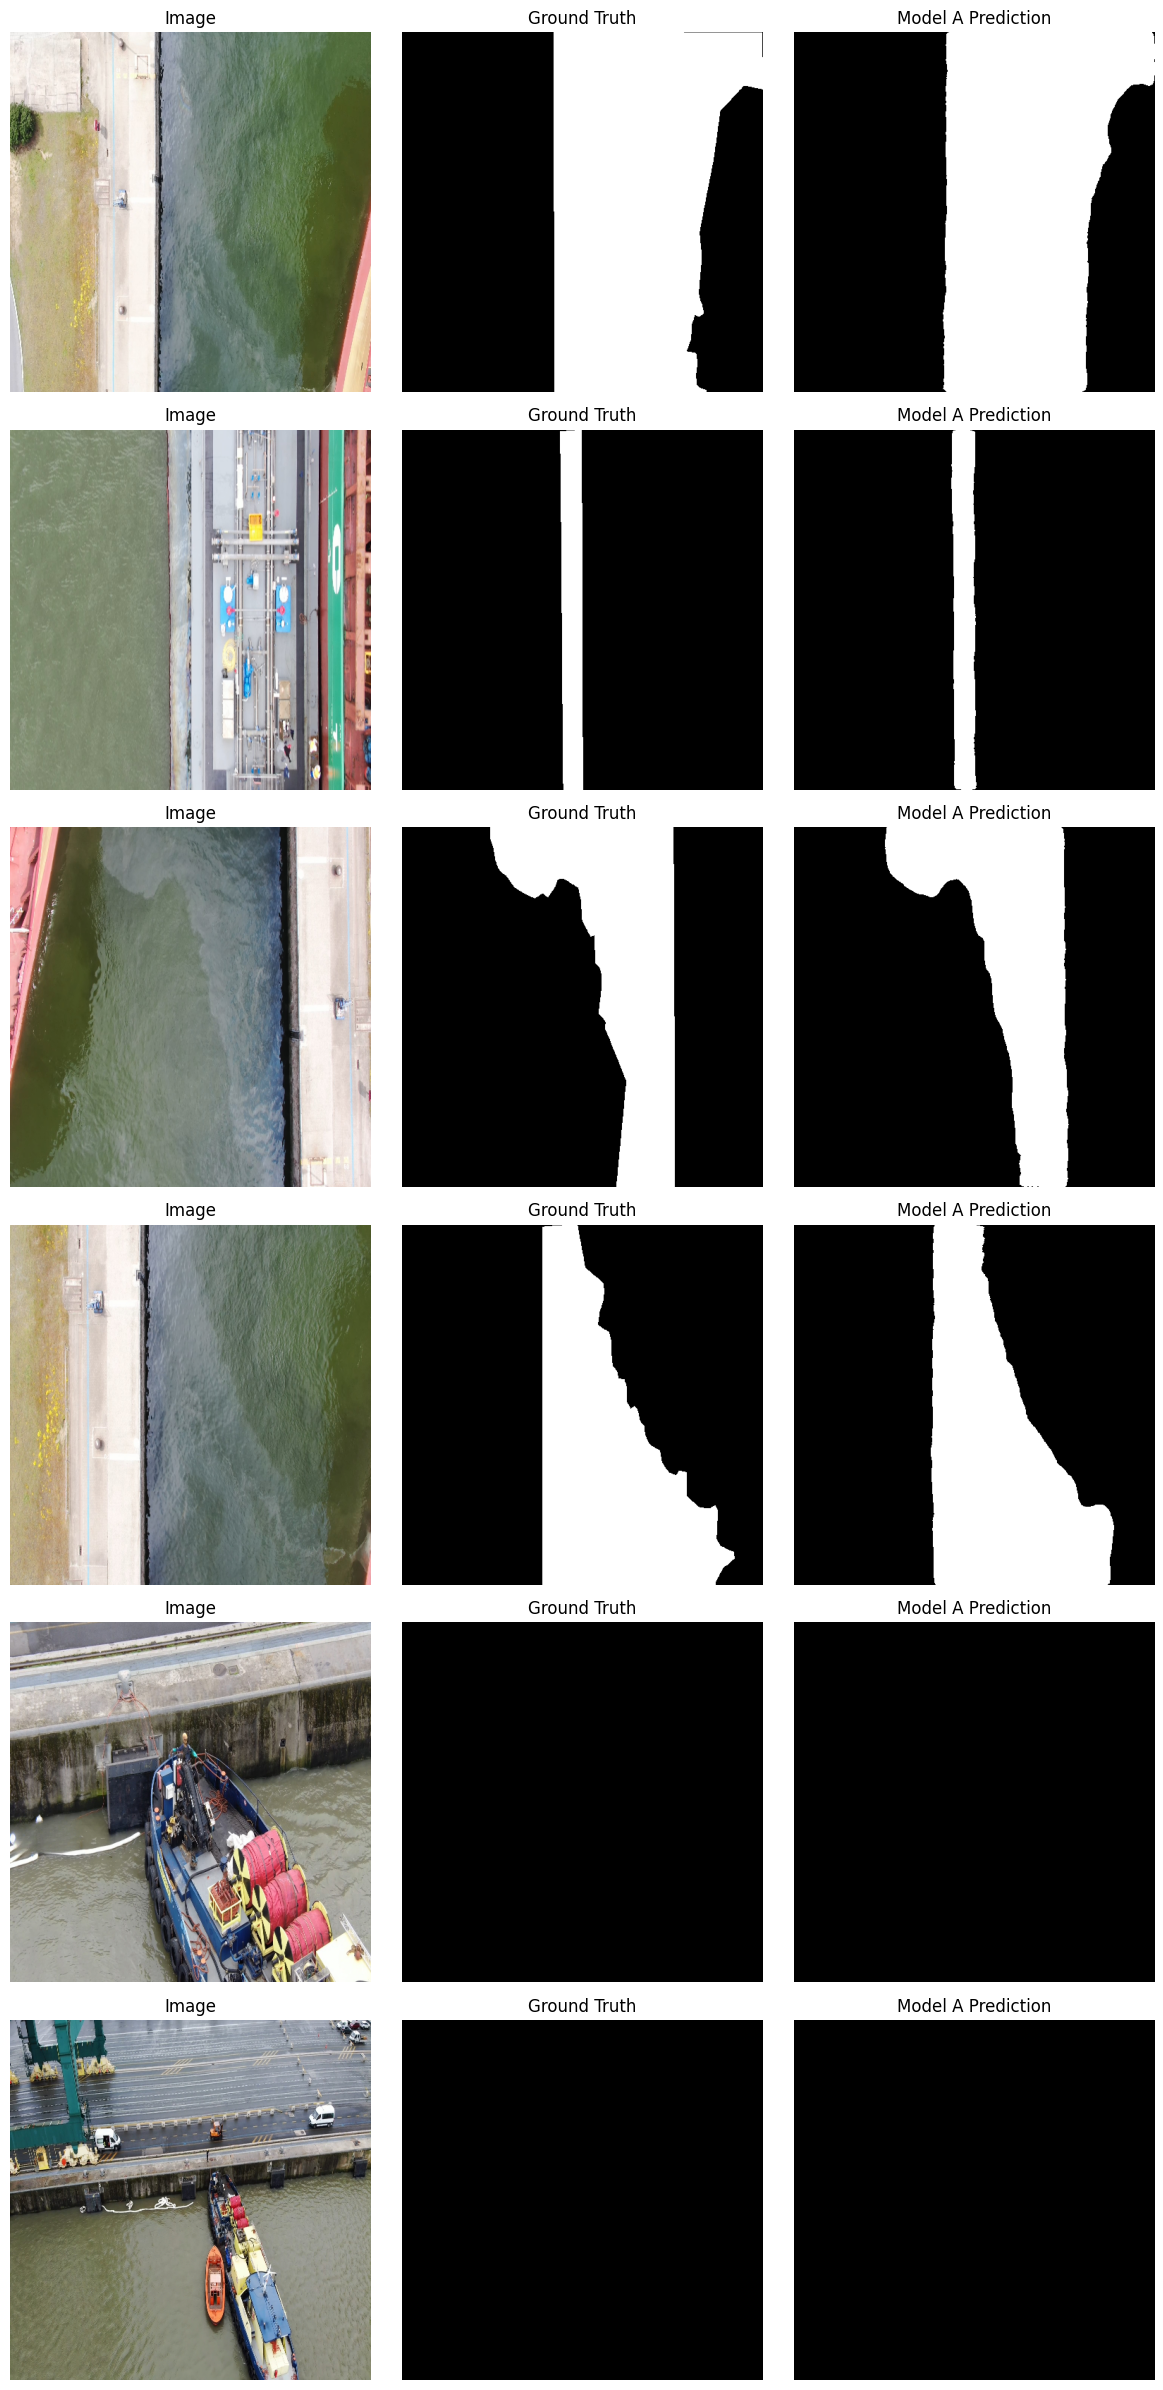

In [ ]:
@torch.no_grad()
def visualize_predictions(model, dataset, device, n=6, threshold=0.5, save_path=None):
    model.eval()
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    for row, idx in enumerate(indices):
        image, mask = dataset[idx]
        logits = model(image.unsqueeze(0).to(device))
        pred = (torch.sigmoid(logits) > threshold).float().cpu()[0, 0]

        img_vis = (image * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()

        axes[row, 0].imshow(img_vis); axes[row, 0].set_title("Image"); axes[row, 0].axis("off")
        axes[row, 1].imshow(mask[0].numpy(), cmap="gray"); axes[row, 1].set_title("Ground Truth"); axes[row, 1].axis("off")
        axes[row, 2].imshow(pred.numpy(), cmap="gray"); axes[row, 2].set_title("Model A Prediction"); axes[row, 2].axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Saved prediction visualization to {save_path}")
    plt.show()

visualize_predictions(model_a, test_dataset, DEVICE, n=6,
                       save_path=os.path.join(PLOTS_DIR, "model_a_predictions.png"))


## 9. Training Curves

Saved training curves to /content/drive/MyDrive/oil_spill_project_outputs/plots/model_a_training_curves.png


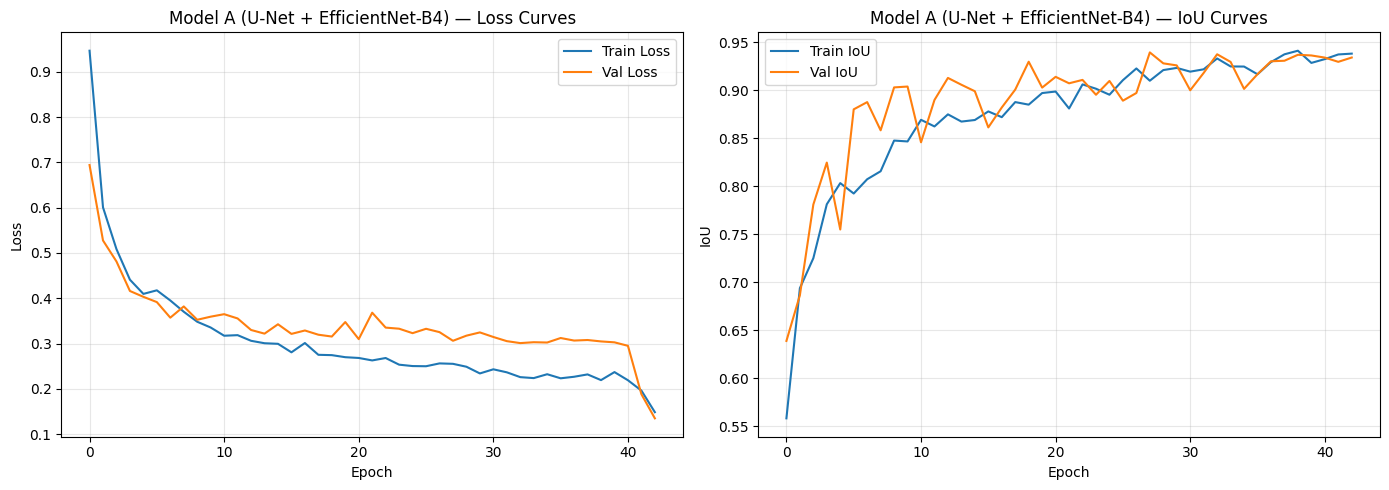

In [ ]:
def plot_training_curves(history, model_name, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"], label="Val Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{model_name} — Loss Curves")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history["train_iou"], label="Train IoU")
    axes[1].plot(history["val_iou"], label="Val IoU")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("IoU")
    axes[1].set_title(f"{model_name} — IoU Curves")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Saved training curves to {save_path}")
    plt.show()

plot_training_curves(history_a, "Model A (U-Net + EfficientNet-B4)",
                      save_path=os.path.join(PLOTS_DIR, "model_a_training_curves.png"))


## Summary

Model A — a standard U-Net with an ImageNet-pretrained EfficientNet-B4 encoder, trained with
Dice + BCE loss — has been trained to convergence (or early-stopped) and evaluated on the
held-out test set. Its checkpoint, training history, test metrics, and prediction
visualizations are saved to Google Drive under `oil_spill_project_outputs/`.

This model serves as the **baseline** in the ablation study: it isolates whether the
EfficientNet-B4 encoder alone, without attention gates or boundary-aware losses, is
sufficient for this task.

**Next:** Notebook 3 implements **Model B** — Attention U-Net with the same EfficientNet-B4
encoder, manually implemented attention gates at every skip connection, trained with
Dice + Focal Loss.
